In [1]:
!pip install polars


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import functools
import itertools
import operator
from typing import Any

import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F

## BCos readout

In [2]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out


class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

## BCos GCN conv layer

In [3]:
class BcosGCNConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        b=2,
        max_out=1,
        *args,
        **kwargs,
    ):
        super().__init__(*args, aggr="add", **kwargs)  # "Add" aggregation (Step 5).
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )

    def forward(self, x, edge_index):
        # Step 1: Add self-loops to the adjacency matrix.
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Step 2: Linearly transform node feature matrix.
        x = self.transform(x)

        # Step 3: Compute normalization.
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float("inf")] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        # Step 4-5: Start propagating messages.
        out = self.propagate(edge_index, x=x, norm=norm)

        return out

    def message(self, x_j, norm):
        # x_j has shape [E, out_channels]

        # Step 4: Normalize node features.
        return norm.view(-1, 1) * x_j

## Bcos GNN


In [4]:
class BCosGNN(torch.nn.Module):
    def __init__(
        self,
        node_size: int,
        hidden_channels: int | list[int],
        conv_layer: type[MessagePassing],
        num_convs: int,
        readout: Readout,
        b: float = 2,
        max_out: int = 1,
        conv_kwargs: dict[str, Any] | None = None,
    ):
        super().__init__()
        if isinstance(hidden_channels, int):
            hidden_channels = [hidden_channels]
        conv_kwargs = conv_kwargs or {}
        self.lin_node = BcosLinear(
            node_size,
            hidden_channels[0],
        )
        self.convs = torch.nn.ModuleList(
            [
                conv_layer(
                    channels=hidden_channels,
                    b=b,
                    max_out=max_out,
                    **conv_kwargs,
                )
                for _ in range(num_convs)
            ]
        )
        self.readout = readout

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        return self.readout(x, batch)

## Dataset creation

In [5]:
ba2_motif = BA2MotifDataset(root="data/BA2Motif")

Processing...
Done!
Processing...
Done!


In [6]:
def get_one_hot_degree_clamped(data, max_degree=10):
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long)
    deg = deg.clamp(max=max_degree)
    one_hot_deg = torch.nn.functional.one_hot(deg, num_classes=max_degree + 1).to(
        torch.float
    )
    data.x = one_hot_deg.float()
    return data

## Train and test logic

In [7]:
def train_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


@torch.inference_mode()
def test_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


def run_epoch(
    step_fn,
    model,
    data_loader,
    criterion,
    optim,
    step_metrics=None,
    epoch_metrics=None,
):
    epoch_metrics = epoch_metrics or {}
    for metric in epoch_metrics.values():
        metric.reset()
    epoch_info = {"steps": []}
    for step_index, batch in enumerate(data_loader):
        step_info = step_fn(model, batch, criterion, optim, step_metrics) | {
            "step_index": step_index
        }
        epoch_info["steps"].append(step_info)
        for metric in epoch_metrics.values():
            metric.update(step_info["pred"].squeeze(), batch.y)
    for name, metric in epoch_metrics.items():
        epoch_info[name] = metric.compute()
    return epoch_info


def train_and_test_model(
    model: BCosGNN,
    dataset: BA2MotifDataset,
    transform,
    train_split: torch.tensor,
    test_split: torch.tensor,
    num_train_epochs: int,
    lr: float,
    batch_size: int,
):
    dataset.transform = transform
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEWithLogitsLoss()
    train_loader = DataLoader(dataset[train_split], batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset[test_split], batch_size=batch_size, shuffle=False)
    train_epochs = [
        run_epoch(
            train_step,
            model,
            train_loader,
            criterion,
            optim,
            step_metrics=None,
            #epoch_metrics={"auroc": AUROC("binary")},
            epoch_metrics={"accuracy": BinaryAccuracy()},
        )
        | {"epoch_index": epoch_index}
        for epoch_index in tqdm(
            range(num_train_epochs), f"Training {model.__class__.__name__}"
        )
    ]
    test_epoch = run_epoch(
        test_step,
        model,
        test_loader,
        criterion,
        optim,
        step_metrics=None,
        #epoch_metrics={"auroc": AUROC("binary")}
        epoch_metrics={"accuracy": BinaryAccuracy()},
    )
    return train_epochs, test_epoch

In [8]:
def get_many(d, *keys):
    return {d[key] for key in keys}


def to_polars(train_epochs, test_epoch, **markers):
    df_epoch = pl.DataFrame(
        {
            "epoch_index": [epoch["epoch_index"] for epoch in train_epochs] + [0],
            "accuracy": [epoch["accuracy"].item() for epoch in train_epochs]
            + [test_epoch["accuracy"]],
            "split": ["train"] * len(train_epochs) + ["test"],
        }
    )
    if len(markers) > 0:
        df_epoch = df_epoch.with_columns(
            *[
                pl.lit(marker_value).alias(marker_key)
                for marker_key, marker_value in markers.items()
            ]
        )
    return df_epoch, None

In [9]:
dataset = ba2_motif
train_split, test_split = train_test_split(
    np.arange(len(dataset)), test_size=0.2, train_size=0.8, random_state=42
)
train_hyperparams = {
    "num_train_epochs": 40,
    "batch_size": 64,
    "lr": 3e-4,
}

interventions = {
    "conv_capacity": {
        "64": dict(
            hidden_channels=64,
        ),
        "64,64": dict(hidden_channels=[64, 64]),
    },
    "readout_order": {
        "agg_then_readout": dict(readout_cls=AggThenReadout),
        "readout_then_agg": dict(readout_cls=ReadoutThenAgg),
    },
    "readout_capacity": {
        "64": dict(
            readout_hidden_channels=64,
        ),
        "64,64": dict(readout_hidden_channels=[64, 64]),
    },
    "feature_transform": {
        "none": dict(transform=None, node_size=10),
        "degree": dict(
            transform=functools.partial(get_one_hot_degree_clamped, max_degree=4),
            node_size=5,
        ),
    },
}


# Generate all combinations
keys = list(interventions.keys())
values_product = itertools.product(*(interventions[k].items() for k in keys))

default_model_hyperparams = dict(
    transform=None,
    conv_layer=BcosGCNConv,
    num_convs=3,
    readout_cls=AggThenReadout,
    readout_in_channels=64,
    readout_hidden_channels=64,
    b=2,
    max_out=1,
)
dfs = []
for combo in values_product:
    # combo is a tuple of (key, value_dict) pairs for each intervention category
    intrv = {k: name for k, (name, _) in zip(keys, combo)}
    hyperparam_changes = [params for _, params in combo]
    hyperparams = functools.reduce(
        operator.or_, hyperparam_changes, default_model_hyperparams
    )

    print("intervention:", intrv)
    print("hyperparams:", hyperparams)
    model = BCosGNN(
        node_size=hyperparams["node_size"],
        hidden_channels=hyperparams["hidden_channels"],
        conv_layer=hyperparams["conv_layer"],
        num_convs=hyperparams["num_convs"],
        readout=hyperparams["readout_cls"](
            in_channels=hyperparams["readout_in_channels"],
            hidden_channels=hyperparams["readout_hidden_channels"],
            b=hyperparams["b"],
            max_out=hyperparams["max_out"],
        ),
        b=hyperparams["b"],
        max_out=hyperparams["max_out"],
    )
    train_epochs, test_epoch = train_and_test_model(
        model=model,
        dataset=dataset,
        transform=hyperparams["transform"],
        train_split=train_split,
        test_split=test_split,
        **train_hyperparams,
    )
    df_train, df_test = to_polars(
        train_epochs=train_epochs, test_epoch=test_epoch, **intrv
    )
    dfs.append(df_train)

df = pl.concat(dfs)

intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': 64, 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 10}


Training BCosGNN: 100%|██████████| 40/40 [00:02<00:00, 14.67it/s]



intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64', 'feature_transform': 'degree'}
hyperparams: {'transform': functools.partial(<function get_one_hot_degree_clamped at 0x79b01f535e40>, max_degree=4), 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': 64, 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 5}


Training BCosGNN: 100%|██████████| 40/40 [00:04<00:00,  9.02it/s]



intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64,64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 10}


...

Training BCosGNN: 100%|██████████| 40/40 [00:05<00:00,  6.69it/s]



intervention: {'conv_capacity': '64,64', 'readout_order': 'readout_then_agg', 'readout_capacity': '64,64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.ReadoutThenAgg'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': [64, 64], 'node_size': 10}


Training BCosGNN: 100%|██████████| 40/40 [00:04<00:00,  8.64it/s]



intervention: {'conv_capacity': '64,64', 'readout_order': 'readout_then_agg', 'readout_capacity': '64,64', 'feature_transform': 'degree'}
hyperparams: {'transform': functools.partial(<function get_one_hot_degree_clamped at 0x79b01f535e40>, max_degree=4), 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.ReadoutThenAgg'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': [64, 64], 'node_size': 5}


Training BCosGNN: 100%|██████████| 40/40 [00:06<00:00,  6.30it/s]



In [10]:
df

epoch_index,accuracy,split,conv_capacity,readout_order,readout_capacity,feature_transform
i64,f64,str,str,str,str,str
0,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
1,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
2,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
3,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
4,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
…,…,…,…,…,…,…
36,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""
37,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""
38,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""


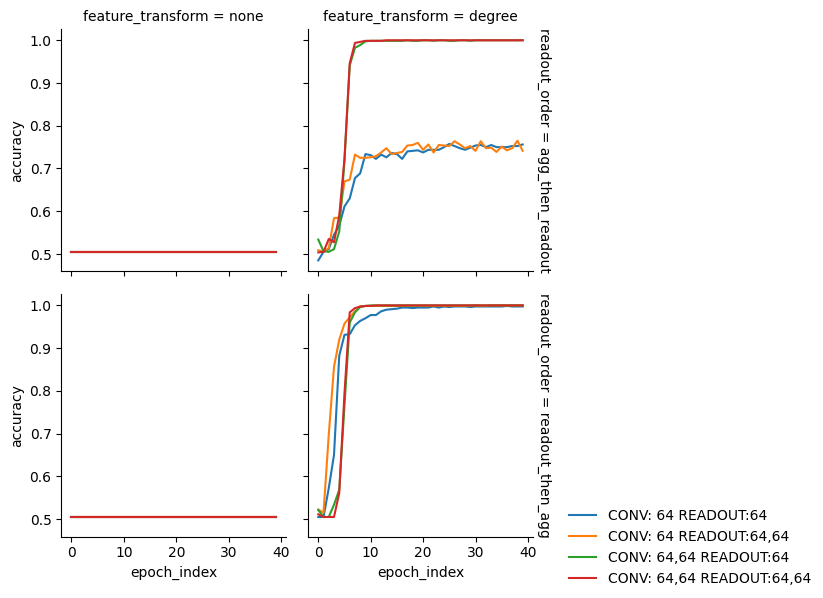

In [11]:
g = sns.FacetGrid(
    df.filter(pl.col("split") == "train").with_columns(
        pl.concat_str(
            pl.lit("CONV: "),
            pl.col("conv_capacity"),
            pl.lit(" READOUT:"),
            pl.col("readout_capacity"),
        ).alias("model_capacity")
    ),
    col="feature_transform",
    
    row="readout_order",
    margin_titles=True,
)
g.map_dataframe(sns.lineplot, x="epoch_index", y="accuracy", hue="model_capacity")
g.add_legend()
sns.move_legend(g, loc="lower right")

In [12]:
df.filter(pl.col("split") == "test", pl.col("feature_transform") == "degree")

epoch_index,accuracy,split,conv_capacity,readout_order,readout_capacity,feature_transform
i64,f64,str,str,str,str,str
0,0.805,"""test""","""64""","""agg_then_readout""","""64""","""degree"""
0,0.795,"""test""","""64""","""agg_then_readout""","""64,64""","""degree"""
0,1.0,"""test""","""64""","""readout_then_agg""","""64""","""degree"""
0,1.0,"""test""","""64""","""readout_then_agg""","""64,64""","""degree"""
0,1.0,"""test""","""64,64""","""agg_then_readout""","""64""","""degree"""
0,1.0,"""test""","""64,64""","""agg_then_readout""","""64,64""","""degree"""
0,1.0,"""test""","""64,64""","""readout_then_agg""","""64""","""degree"""
0,1.0,"""test""","""64,64""","""readout_then_agg""","""64,64""","""degree"""


In [13]:
best_hyperparams = {
    "node_size": 5,
    "hidden_channels": [64 , 64],
    "conv_layer": BcosGCNConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels=[64, 64],
        b=2,
        max_out=1,
    ),
    "b": 2,
    "max_out": 1,
}

In [14]:
best_model = BCosGNN(**best_hyperparams)

In [15]:
train_epochs, test_epoch = train_and_test_model(
    model=best_model,
    dataset=dataset,
    transform=functools.partial(get_one_hot_degree_clamped, max_degree=4),
    train_split=train_split,
    test_split=test_split,
    **train_hyperparams,
)

Training BCosGNN: 100%|██████████| 40/40 [00:06<00:00,  6.59it/s]



In [16]:
print(f"Test Accuracy for best model: {test_epoch['accuracy']:.4f}")

Test Accuracy for best model: 1.0000


In [20]:
best_model.eval()
dataset.transform = None 

# 1. Get the graph view object from the dataset
graph_view = dataset[test_split[0]]

# 2. Create a clean, standard Data object from the view
# This forces all attributes (like edge_mask) to be loaded.
raw_graph = Data(
    x=graph_view.x, 
    edge_index=graph_view.edge_index, 
    y=graph_view.y, 
)

# 3. Now, apply the transform to the clean Data object
transform_fn = functools.partial(get_one_hot_degree_clamped, max_degree=4)
graph_to_explain = transform_fn(raw_graph)

In [21]:
with torch.no_grad():
    # Forward pass to get node embeddings
    x = best_model.lin_node(graph_to_explain.x)
    for conv in best_model.convs:
        x = conv(x, graph_to_explain.edge_index)

    readout_weights = next(best_model.readout.readout[-1].parameters()) 

    node_importance = F.cosine_similarity(x, readout_weights)

    prediction = best_model(graph_to_explain.x, graph_to_explain.edge_index, torch.zeros(graph_to_explain.num_nodes, dtype=torch.long))

predicted_prob = torch.sigmoid(prediction).item()
predicted_label = 1 if predicted_prob > 0.5 else 0

print(f"True Label: {graph_to_explain.y.item()}")
print(f"Predicted Label: {predicted_label}")
print(f"Model Prediction (Probability): {predicted_prob:.4f}")

True Label: 1
Predicted Label: 1
Model Prediction (Probability): 1.0000


In [22]:
def visualize_explanation(graph_data, node_importance):
    g = nx.Graph()
    g.add_nodes_from(range(graph_data.num_nodes))
    g.add_edges_from(graph_data.edge_index.t().tolist())

    plt.figure(figsize=(8, 8))
    
    node_colors = node_importance.numpy()
    
    edge_colors = [max(node_colors[u], node_colors[v]) for u, v in g.edges()]

    pos = nx.spring_layout(g, seed=42)
    
    nodes = nx.draw_networkx_nodes(g, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=500)
    edges = nx.draw_networkx_edges(g, pos, edge_color=edge_colors, edge_cmap=plt.cm.viridis, width=2)
    nx.draw_networkx_labels(g, pos, font_color='white')

    plt.colorbar(nodes, label="Node Importance (Cosine Similarity)")
    plt.title("Explanation for a single graph")
    plt.show()

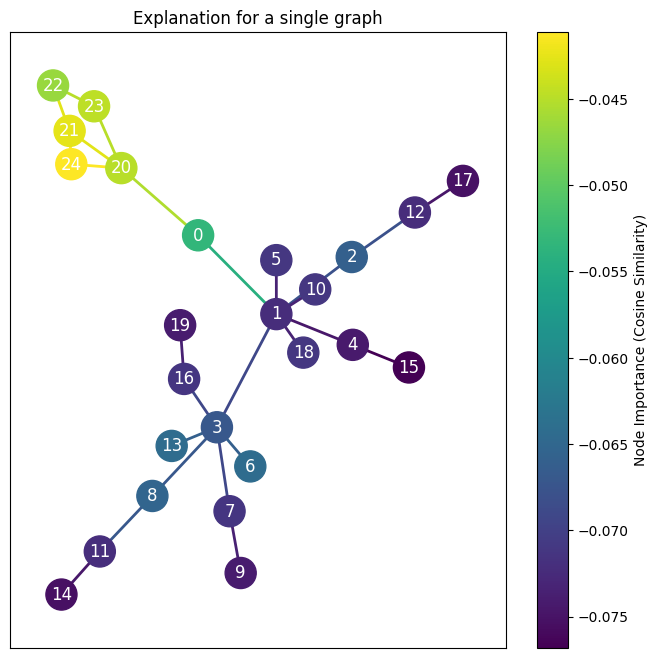

In [23]:
visualize_explanation(graph_to_explain, node_importance)

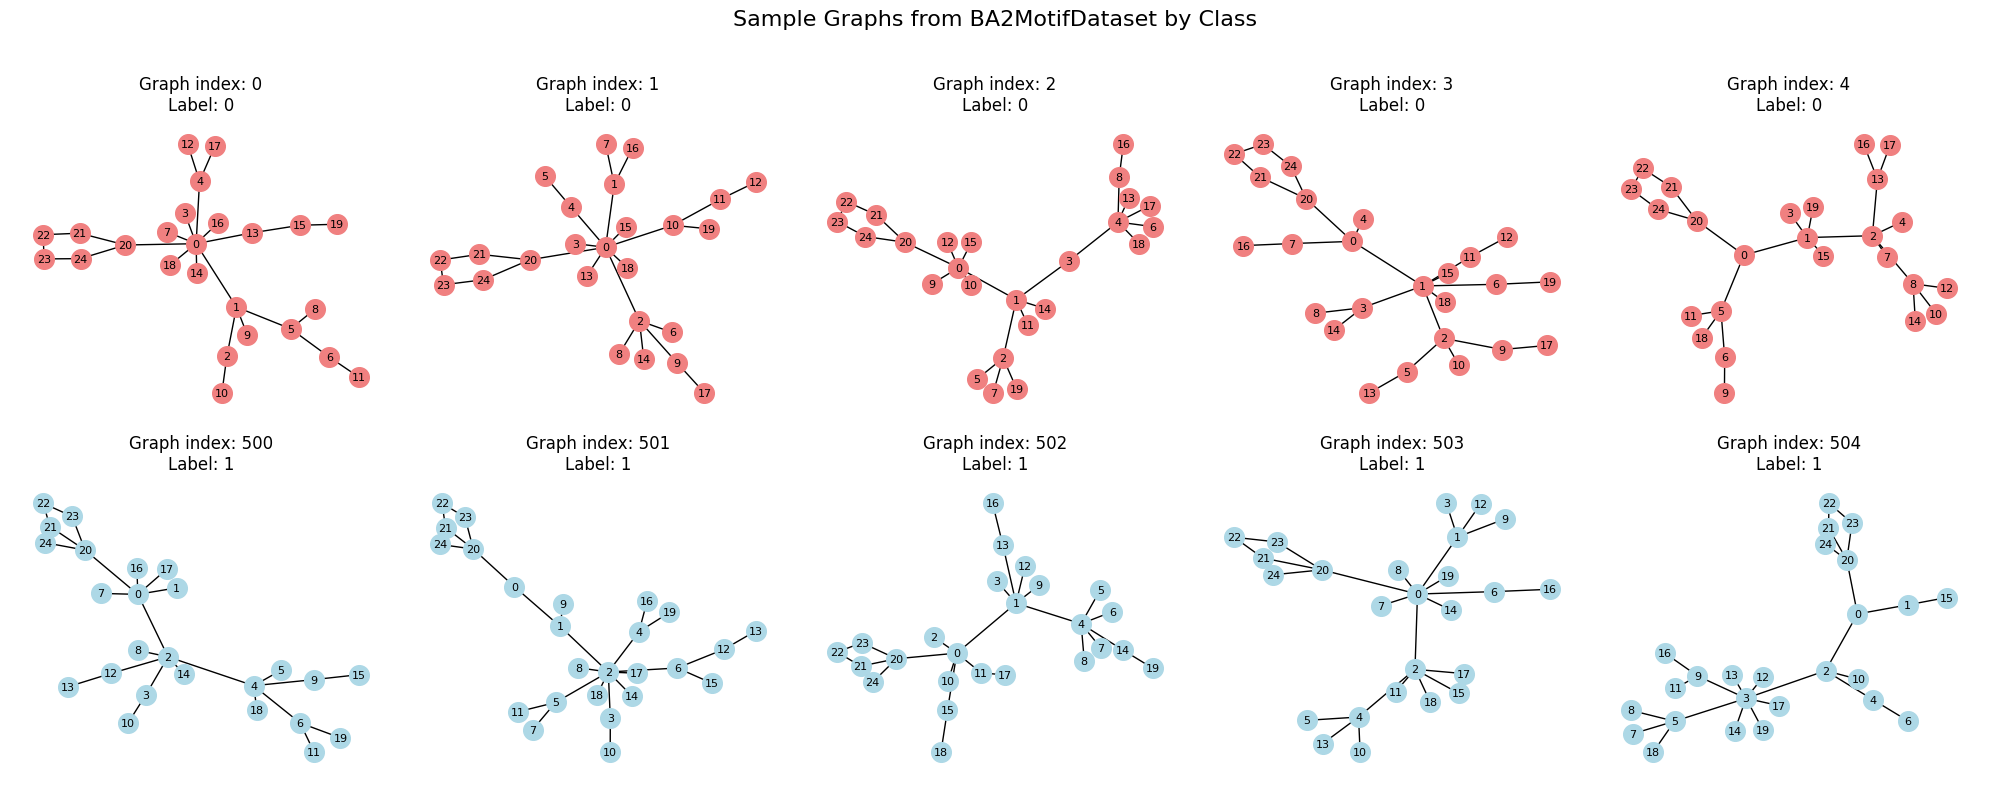

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import BA2MotifDataset

class_0_samples = []
class_1_samples = []
class_0_indices = []
class_1_indices = []

dataset_for_plotting = BA2MotifDataset(root="data/BA2Motif")
dataset_for_plotting.transform = None

for i, data in enumerate(dataset_for_plotting):
    if data.y.item() == 0 and len(class_0_samples) < 5:
        class_0_samples.append(data)
        class_0_indices.append(i)
    elif data.y.item() == 1 and len(class_1_samples) < 5:
        class_1_samples.append(data)
        class_1_indices.append(i)
    
    if len(class_0_samples) == 5 and len(class_1_samples) == 5:
        break

# 2. Visualize the samples
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Sample Graphs from BA2MotifDataset by Class", fontsize=16)

# Plot Class 0 graphs
for i, data in enumerate(class_0_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=True, node_color='lightcoral', node_size=200, font_size=8)
    ax.set_title(f"Graph index: {class_0_indices[i]}\nLabel: 0")

# Plot Class 1 graphs
for i, data in enumerate(class_1_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=True, node_color='lightblue', node_size=200, font_size=8)
    ax.set_title(f"Graph index: {class_1_indices[i]}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [25]:
num_nodes = graph_to_explain.num_nodes
ground_truth_nodes = torch.arange(num_nodes - 5, num_nodes)

print(f"Ground truth motif nodes: {ground_truth_nodes.numpy()}")

# Get the top-k most important nodes from our explanation
k = len(ground_truth_nodes)
top_k_nodes = torch.topk(node_importance, k).indices

print(f"Top {k} most important nodes from explanation: {top_k_nodes.numpy()}")

# --- Quantify the explanation ---
# How many of our top_k nodes are in the ground_truth_nodes?
correctly_identified_nodes = np.intersect1d(ground_truth_nodes.numpy(), top_k_nodes.cpu().numpy())

# Ensure k is not zero to avoid division by zero
if k > 0:
    accuracy = len(correctly_identified_nodes) / k
    print(f"\nExplanation Accuracy: {accuracy:.2%}")
    print(f"Identified {len(correctly_identified_nodes)} out of {k} motif nodes correctly.")
else:
    print("\nNo ground truth nodes found.")

Ground truth motif nodes: [20 21 22 23 24]
Top 5 most important nodes from explanation: [24 21 23 20 22]

Explanation Accuracy: 100.00%
Identified 5 out of 5 motif nodes correctly.
